# SHine-K — Reproducibility & Figures (Google Colab)

All paper figures (Fig. 1–4) and the recovery-exercise GIFs are generated here, so they can be **edited and re-generated during revision**. Output is saved under `figures/` and shown inline.

Conceptual basis (KOSHA/RISE requirement analysis): the system targets both acute **accident hazards** and **cumulative hazards** (chronic health), motivating integrated safety + health with a closed feedback loop.

Paper: *Design and Implementation of a Simulation-Based Web Platform for Integrated AI Worker Safety and Health Monitoring in SMEs (SHine-K)*.

> **This notebook produces design illustrations + measurements, with honest separation.** Each run writes a timestamped folder `output/run_YYYYMMDD_HHMMSS/` (figures, logs, manifest, and — when run in Colab with internet — the URFD fall-detection result). Hand-drawn figures are *design*, not results; the fall-detection eval and the latency micro-bench are the measured parts (the latter is post-processing overhead only).

In [1]:
!pip -q install matplotlib pillow


In [2]:
# === RUN SETUP — per-run output folder + provenance (added) ===
import os, sys, json, time, platform, subprocess, hashlib, shutil, random
from pathlib import Path
from datetime import datetime, timezone, timedelta
import numpy as np

SEED = 12345
random.seed(SEED); np.random.seed(SEED)   # figures/GIFs are deterministic; timing varies (reported as variance)

def _in_colab():
    try:
        import google.colab  # noqa
        return True
    except Exception:
        return False
IN_COLAB = _in_colab()

# Where the repo lives (for native Mac runs and for the Drive mirror)
REPO_LOCAL = Path("/Users/y3korea/Library/CloudStorage/GoogleDrive-y3korea@gmail.com/내 드라이브/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문3/코드")
DRIVE_REPO = None
if IN_COLAB:
    try:
        from google.colab import drive
        if not os.path.ismount("/content/drive"):
            drive.mount("/content/drive")               # idempotent; no force_remount
        cand = Path("/content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문3/코드")
        DRIVE_REPO = cand if cand.exists() else None
    except Exception as e:
        print("Drive mount skipped:", e)

# Primary write target: fast + never truncates. Colab=/content; local Mac=repo output/.
if IN_COLAB:
    BASE_OUTPUT = Path("/content/output")
elif REPO_LOCAL.exists():
    BASE_OUTPUT = REPO_LOCAL / "output"
else:
    BASE_OUTPUT = Path("./output")
BASE_OUTPUT.mkdir(parents=True, exist_ok=True)

# Timestamp: folder name in KST (author-friendly); manifest records BOTH utc & kst (Colab clock is UTC).
KST = timezone(timedelta(hours=9))
_utc = datetime.now(timezone.utc)
_kst = _utc.astimezone(KST)
RUN_ID = "run_" + _kst.strftime("%Y%m%d_%H%M%S")
RUN_DIR = BASE_OUTPUT / RUN_ID
FIG_DIR = RUN_DIR / "figures"
REC_DIR = FIG_DIR / "recovery"
LOG_DIR = RUN_DIR / "logs"
for d in (FIG_DIR, REC_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# The figure/GIF cells read these env vars (default ./figures if run standalone)
os.environ["OUT_FIG"] = str(FIG_DIR)
os.environ["OUT_REC"] = str(REC_DIR)

RUN_TIMES = {"utc_iso": _utc.isoformat(), "kst_iso": _kst.isoformat(), "tz_offset": "+09:00", "epoch": _utc.timestamp()}
print("RUN_ID   :", RUN_ID)
print("RUN_DIR  :", RUN_DIR)
print("IN_COLAB :", IN_COLAB, "| Drive mirror:", "yes" if DRIVE_REPO else "no")


Mounted at /content/drive
RUN_ID   : run_20260627_231823
RUN_DIR  : /content/output/run_20260627_231823
IN_COLAB : True | Drive mirror: yes


## 1. Figures (Fig. 1–4, 300 dpi) — edit freely below, then re-run
Academic block-diagram style. Saved to `figures/*.png`.


> These are **author-drawn block diagrams (design illustrations)** — include them under *Design/Architecture*, never under *Results*.

In [3]:
# -*- coding: utf-8 -*-
"""SHine-K paper figures — clean academic block diagrams, 300 dpi.
   v2: overlap-free, publication quality (no line/text collisions). Set OUT to redirect output."""
import os, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Polygon, Circle

EDGE="#1a1a1a"; FILL="#ffffff"; GREY="#eef1f6"; TXT="#000000"
OUT=os.environ.get("OUT_FIG","./figures"); os.makedirs(OUT, exist_ok=True)
plt.rcParams.update({"font.family":"DejaVu Sans","text.color":TXT,
    "axes.edgecolor":EDGE,"savefig.facecolor":"white"})

def rect(ax,x,y,w,h,fc=FILL,lw=1.0,ls="-"):
    ax.add_patch(Rectangle((x,y),w,h,fc=fc,ec=EDGE,lw=lw,ls=ls,joinstyle="round"))
def txt(ax,x,y,s,fs=9,bold=False,it=False,ha="center",va="center",bg=None,color=TXT):
    bbox=dict(boxstyle="round,pad=0.2",fc=bg,ec="none") if bg else None
    ax.text(x,y,s,ha=ha,va=va,fontsize=fs,color=color,zorder=5,
            fontweight="bold" if bold else "normal",fontstyle="italic" if it else "normal",bbox=bbox)
def arr(ax,x1,y1,x2,y2,lw=1.1,ls="-"):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle="-|>",mutation_scale=12,
                 color=EDGE,lw=lw,ls=ls,shrinkA=1,shrinkB=1,zorder=3))

def newax(w,h,ymax=100):
    fig,ax=plt.subplots(figsize=(w,h)); ax.set_xlim(0,100); ax.set_ylim(0,ymax); ax.axis("off")
    ax.set_aspect("auto"); fig.patch.set_facecolor("white"); return fig,ax

def save(fig,name):
    fig.savefig(f"{OUT}/{name}",dpi=300,bbox_inches="tight",pad_inches=0.06); plt.close(fig)

# ---------- Fig 1. Architecture (Sense -> Judge -> Act -> Connect) ----------
def fig1():
    fig,ax=newax(9,3.9)
    stages=[("SENSE",["Vision (MediaPipe/YOLO)","Radar (mmWave)","Wearable (BLE)","Thermal / IoT"]),
            ("JUDGE",["Fusion (multimodal)","Risk predictor (LSTM)","Posture index (2-cue, 33 kpt)"]),
            ("ACT",["Nudge (haptic)","Health feedback","Task / staffing"]),
            ("CONNECT",["Emergency 119/e-Gen","Evacuation, roll-call","Realtime (Supabase)"])]
    colw=22; gap=2; x0=3; y=16; H=74
    for i,(name,nodes) in enumerate(stages):
        x=x0+i*(colw+gap)
        rect(ax,x,y,colw,H,fc=GREY,lw=1.1)
        txt(ax,x+colw/2,y+H-7,name,fs=11,bold=True)
        top=y+H-15; bot=y+5; n=len(nodes); slot=(top-bot)/n
        for j,nd in enumerate(nodes):
            cy=top-slot*(j+0.5); bh=min(9,slot-2.5)
            rect(ax,x+1.5,cy-bh/2,colw-3,bh,fc=FILL,lw=0.9); txt(ax,x+colw/2,cy,nd,fs=6.8)
        if i<3: arr(ax,x+colw,y+H/2,x+colw+gap,y+H/2)
    xL=x0; xR=x0+3*(colw+gap)+colw; yb=7
    ax.plot([xR,xR],[y,yb],color=EDGE,lw=1.0); ax.plot([xL,xL],[yb,y],color=EDGE,lw=1.0)
    arr(ax,xR,yb,xL,yb)
    txt(ax,(xL+xR)/2,yb+3.0,"Feedback loop: personalized rest / stretch → re-measure",fs=7.6,it=True,bg="white")
    save(fig,"fig1_architecture.png")

# ---------- Fig 2. Web composition (modules) ----------
def fig2():
    fig,ax=newax(9,4.0)
    mods=[("(1) Landing","intro, KO/EN/ZH"),
          ("(2) Worksite Edge-AI","in-browser pose, events"),
          ("(3) Control Center","multi-site digital twin"),
          ("(4) Worker App (PWA)","check-in, evac., wearable"),
          ("(5) AI Posture-strain index","BlazePose 33 keypoints"),
          ("(6) Site Camera","fire pixel analysis"),
          ("(7) Paper","manuscript")]
    cols=4; w=22.6; h=24; gx=2.0; gy=12; x0=2.6; y0=58
    for i,(t,s) in enumerate(mods):
        r=i//cols; c=i%cols; x=x0+c*(w+gx); y=y0-r*(h+gy)
        rect(ax,x,y,w,h,fc=FILL,lw=1.1)
        rect(ax,x,y+h-8,w,8,fc=GREY,lw=1.1)            # title band
        txt(ax,x+w/2,y+h-4,t,fs=7.6,bold=True)
        txt(ax,x+w/2,y+h/2-3,s,fs=6.9)
    save(fig,"fig2_system_overview.png")

# ---------- Fig 3. Edge-privacy dataflow — the image-free boundary (key differentiator) ----------
def fig3():
    fig,ax=newax(9,4.2)
    # (label, implemented?) — dashed = design target
    panels=[("Field (edge / browser)",[("Camera + MoveNet / YOLO",True),("Fire pixel analysis",True),("Wearable (BLE) — design",False)]),
            ("Cloud (Supabase)",[("Realtime DB (events)",True),("Auth, pseudonymized",True),("Edge fn (119 / SMS) — design",False)]),
            ("Control center (web)",[("Multi-site monitoring",True),("Alerts / roll-call",True),("On-demand video (break-glass)",True)])]
    w=24; gap=11; x0=3; y=44; h=48
    xs=[x0+i*(w+gap) for i in range(3)]
    for i,(title,items) in enumerate(panels):
        x=xs[i]
        rect(ax,x,y,w,h,fc=GREY,lw=1.1); txt(ax,x+w/2,y+h-6,title,fs=8.4,bold=True)
        for j,(it,impl) in enumerate(items):
            cy=y+h-16-j*10.5
            rect(ax,x+1.6,cy-4,w-3.2,8,fc=FILL,lw=0.9,ls=("-" if impl else "--")); txt(ax,x+w/2,cy,it,fs=6.7)
    ymid=y+h/2
    # bold image-free boundary on Field->Cloud
    gx0=xs[0]+w; gx1=xs[1]
    arr(ax,gx0,ymid,gx1,ymid,lw=2.2)
    txt(ax,(gx0+gx1)/2,ymid+7,"17 skeleton coords\n+ events — NO pixels",fs=6.3,bold=True,bg="white")
    gx0=xs[1]+w; gx1=xs[2]; arr(ax,gx0,ymid,gx1,ymid,lw=1.2); txt(ax,(gx0+gx1)/2,ymid+6,"realtime push",fs=6.6,bg="white")
    # caption
    rect(ax,6,8,88,20,fc=FILL,lw=1.0)
    txt(ax,50,18,"During continuous monitoring no pixels (raw or anonymized) leave the site — only\n"
                 "de-identified skeleton coordinates and structured events. On-demand video uses a\n"
                 "consent-gated, time-limited (60 s), audit-logged 'break-glass' gate.",fs=7.4)
    # legend
    ax.plot([20,24],[3.5,3.5],color=EDGE,lw=1.6); ax.text(25,3.5,"implemented / validated",fontsize=6.4,va="center")
    ax.plot([55,59],[3.5,3.5],color=EDGE,lw=1.0,ls="--"); ax.text(60,3.5,"design target",fontsize=6.4,va="center")
    save(fig,"fig3_dataflow.png")

# ---------- Fig 4. Closed-loop algorithm workflow (graphical abstract) ----------
def aitag(ax,cx,cy,w,h):
    rect(ax,cx-w/2,cy+h/2-3.0,7.2,3.0,fc=EDGE,lw=0)
    ax.text(cx-w/2+3.6,cy+h/2-1.5,"AI",ha="center",va="center",fontsize=6,color="white",fontweight="bold",zorder=6)
def bc(ax,cx,cy,w,h,s,ai=False,design=False,fs=7.0,ty=None):
    rect(ax,cx-w/2,cy-h/2,w,h,fc=("#f5f7fc" if design else FILL),lw=1.0,ls=("--" if design else "-"))
    txt(ax,cx,(ty if ty is not None else cy),s,fs=fs,color=("#5a5f6b" if design else TXT))
    if ai: aitag(ax,cx,cy,w,h)
def diamond(ax,cx,cy,w,h,s,ai=False,fs=7.0):
    ax.add_patch(Polygon([(cx,cy+h/2),(cx+w/2,cy),(cx,cy-h/2),(cx-w/2,cy)],closed=True,
                 fc=(GREY if ai else FILL),ec=EDGE,lw=1.0,zorder=2))
    txt(ax,cx,cy,s,fs=fs)

def fig4():
    fig,ax=newax(9.2,11.6)
    dl=(0,(4,3))
    # --- legend: validated(solid) vs design-target(dashed) + decision + AI ---
    ax.plot([6,10],[97.9,97.9],color=EDGE,lw=1.7); ax.text(11,97.9,"implemented / validated",fontsize=6.5,va="center")
    ax.plot([40,44],[97.9,97.9],color=EDGE,lw=1.0,ls="--"); ax.text(45,97.9,"design target",fontsize=6.5,va="center")
    ax.add_patch(Polygon([(63.5,99.2),(65,97.9),(63.5,96.6),(62,97.9)],closed=True,fc=FILL,ec=EDGE,lw=1.0))
    ax.text(66.5,97.9,"decision",fontsize=6.5,va="center")
    rect(ax,80,96.6,3,2.8,fc=EDGE,lw=0); ax.text(80+1.5,98,"AI",ha="center",va="center",fontsize=5.2,color="white",fontweight="bold")
    ax.text(84.5,97.9,"AI step",fontsize=6.5,va="center")
    # 1 worker
    bc(ax,50,90,30,5.5,"Worker on the shop floor")
    # 2 SENSE inputs (camera + self-check = implemented; wearable + environment = design target)
    sy=80; sx=[14,38,62,86]
    bc(ax,sx[0],sy,21.5,10,"Camera (edge AI)\nposture · fall · caught-in\nhelmet / mask / vest",ai=True,fs=5.7,ty=79.2)
    bc(ax,sx[1],sy,21,10,"Wearable vitals\nHR / temp",design=True,fs=6.2)
    bc(ax,sx[2],sy,21,10,"Self check-in\nsleep / fatigue / pain",fs=6.2)
    bc(ax,sx[3],sy,21,10,"Environment IoT\ngas / noise",design=True,fs=6.2)
    for x in sx: arr(ax,50,87.25,x,sy+5.0)
    # 3 risk judgement — validated rule-based core + honest PoC note
    bc(ax,50,65,52,11,"Risk judgement: fall state machine (benchmark-validated) + posture index (rule-based)",ai=True,fs=6.6,ty=66.7)
    txt(ax,50,62.6,"+ open agent harness (Sense→Judge→Act→Connect): PoC · interface-level · not evaluated",fs=5.7,it=True,color="#6a6f7b")
    for x in sx: arr(ax,x,sy-5.0,50,70.5)
    # 4 decision
    diamond(ax,50,52,27,12,"Risk type?",fs=8); arr(ax,50,59.5,50,58)
    # left: acute hazard -> emergency
    bc(ax,18,40,30,9,"Acute hazard\nfall / fire / gas / asphyxia",fs=6.5)
    arr(ax,37,52,18,44.5); txt(ax,27,49,"acute",fs=6.5,it=True,bg="white")
    bc(ax,18,25,30,9,"Alert + evacuation & roll-call\n+ 119 / e-Gen (design target)",design=True,fs=6.4)
    arr(ax,18,35.5,18,29.5)
    bc(ax,18,12,30,6,"Emergency resolved",fs=6.6); arr(ax,18,20.5,18,15)
    # right: health/ergonomic risk -> recovery loop
    bc(ax,80,40,30,9,"Health / ergonomic risk\nhigh posture index / fatigue",fs=6.5)
    arr(ax,63,52,80,44.5); txt(ax,72.5,49,"cumulative",fs=6.5,it=True,bg="white")
    bc(ax,80,25,32,10,"Personalized recovery coaching\nrest / stretch (animated guide)",ai=True,fs=6.5)
    arr(ax,80,35.5,80,30)
    bc(ax,80,12,32,7,"Worker performs → confirm done\nlog adherence (design)",fs=6.4); arr(ax,80,20,80,15.5)
    # center: normal -> continue
    arr(ax,50,46,50,36,ls=dl); txt(ax,53.5,41,"normal",fs=6.5,it=True,bg="white")
    bc(ax,50,33,22,6,"Continue monitoring",fs=6.5)
    # closed feedback loop (dashed) up the clear right margin, back into the worker box
    ax.plot([80,80],[8.5,4.5],color=EDGE,lw=1.0,ls=dl)
    ax.plot([80,98],[4.5,4.5],color=EDGE,lw=1.0,ls=dl)
    ax.plot([98,98],[4.5,90],color=EDGE,lw=1.0,ls=dl)
    ax.add_patch(FancyArrowPatch((98,90),(65.5,90),arrowstyle="-|>",mutation_scale=12,color=EDGE,lw=1.0,ls=dl,zorder=3))
    txt(ax,42,1.6,"Closed feedback loop: re-measure & adapt",fs=7.0,it=True)
    save(fig,"fig4_workflow.png")

fig1(); fig2(); fig3(); fig4()
for f in ["fig1_architecture.png","fig2_system_overview.png","fig3_dataflow.png","fig4_workflow.png"]:
    print(f, os.path.getsize(f"{OUT}/{f}")//1024,"KB")


fig1_architecture.png 107 KB
fig2_system_overview.png 78 KB
fig3_dataflow.png 153 KB
fig4_workflow.png 301 KB


fig1_architecture


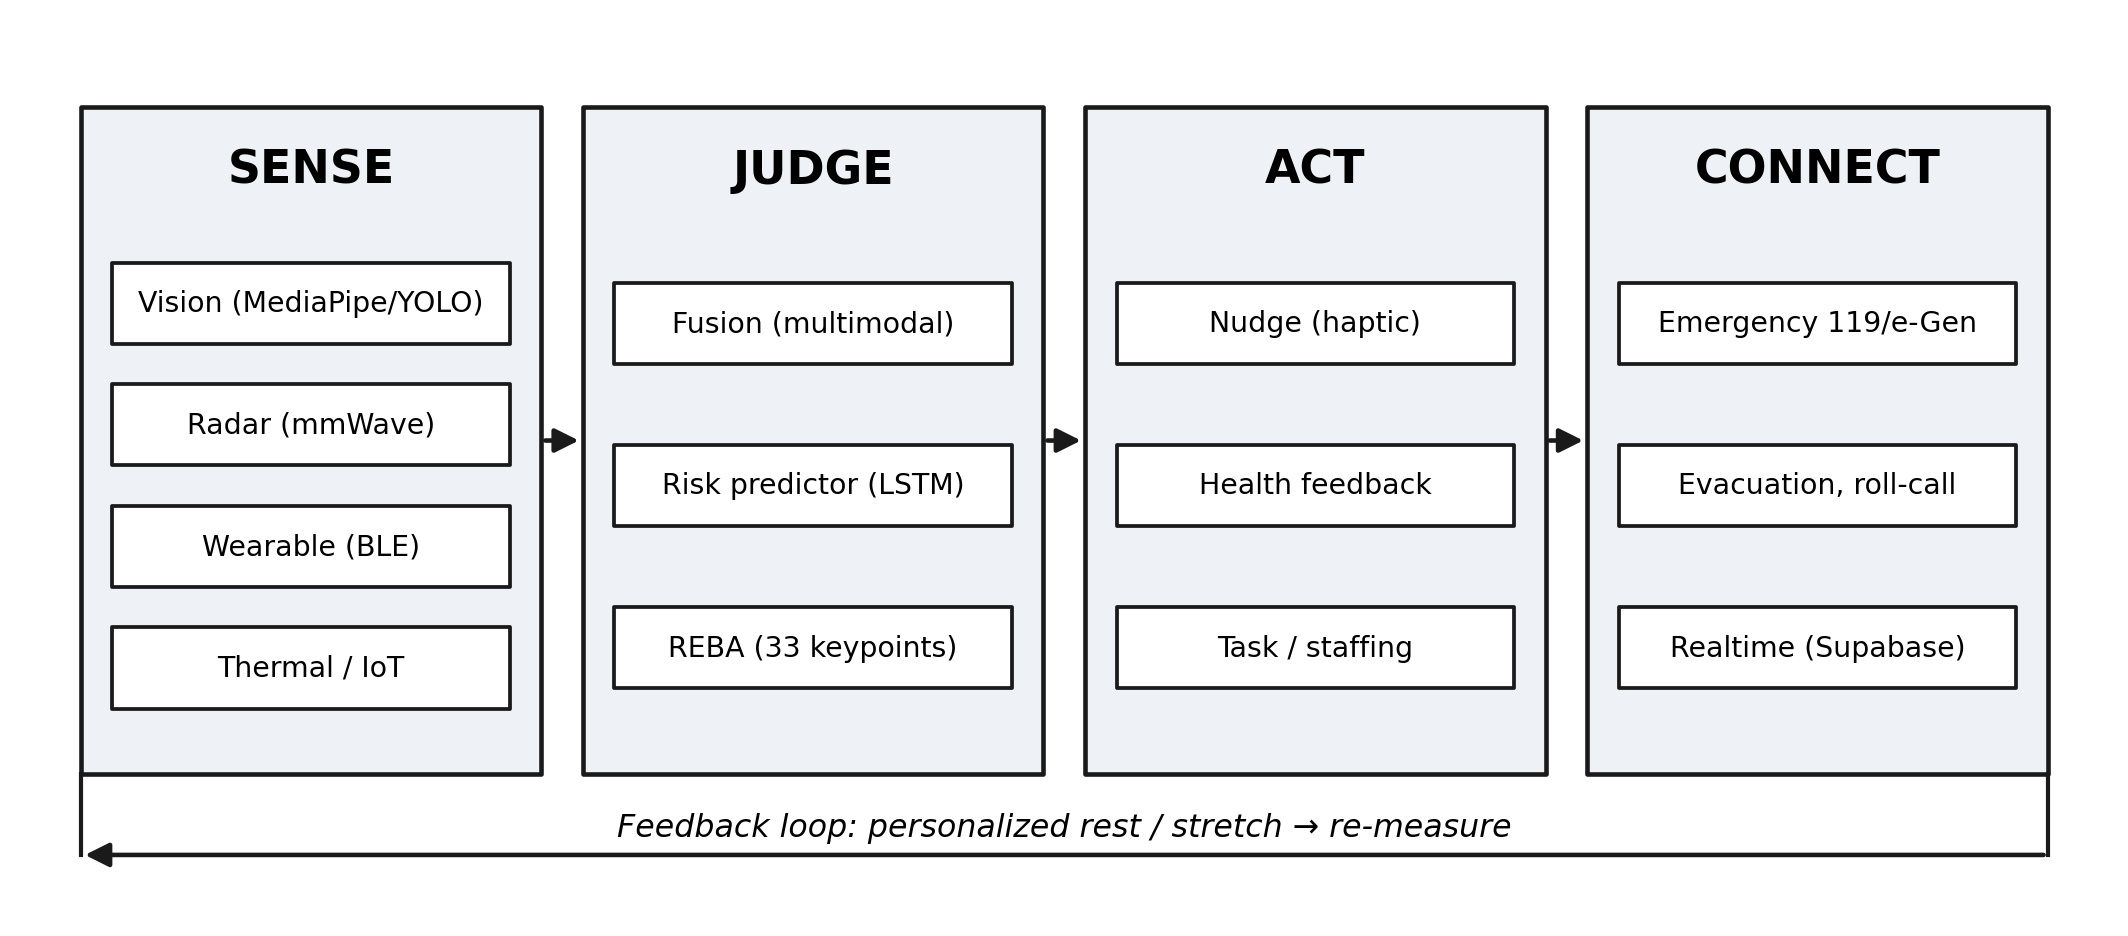

fig2_system_overview


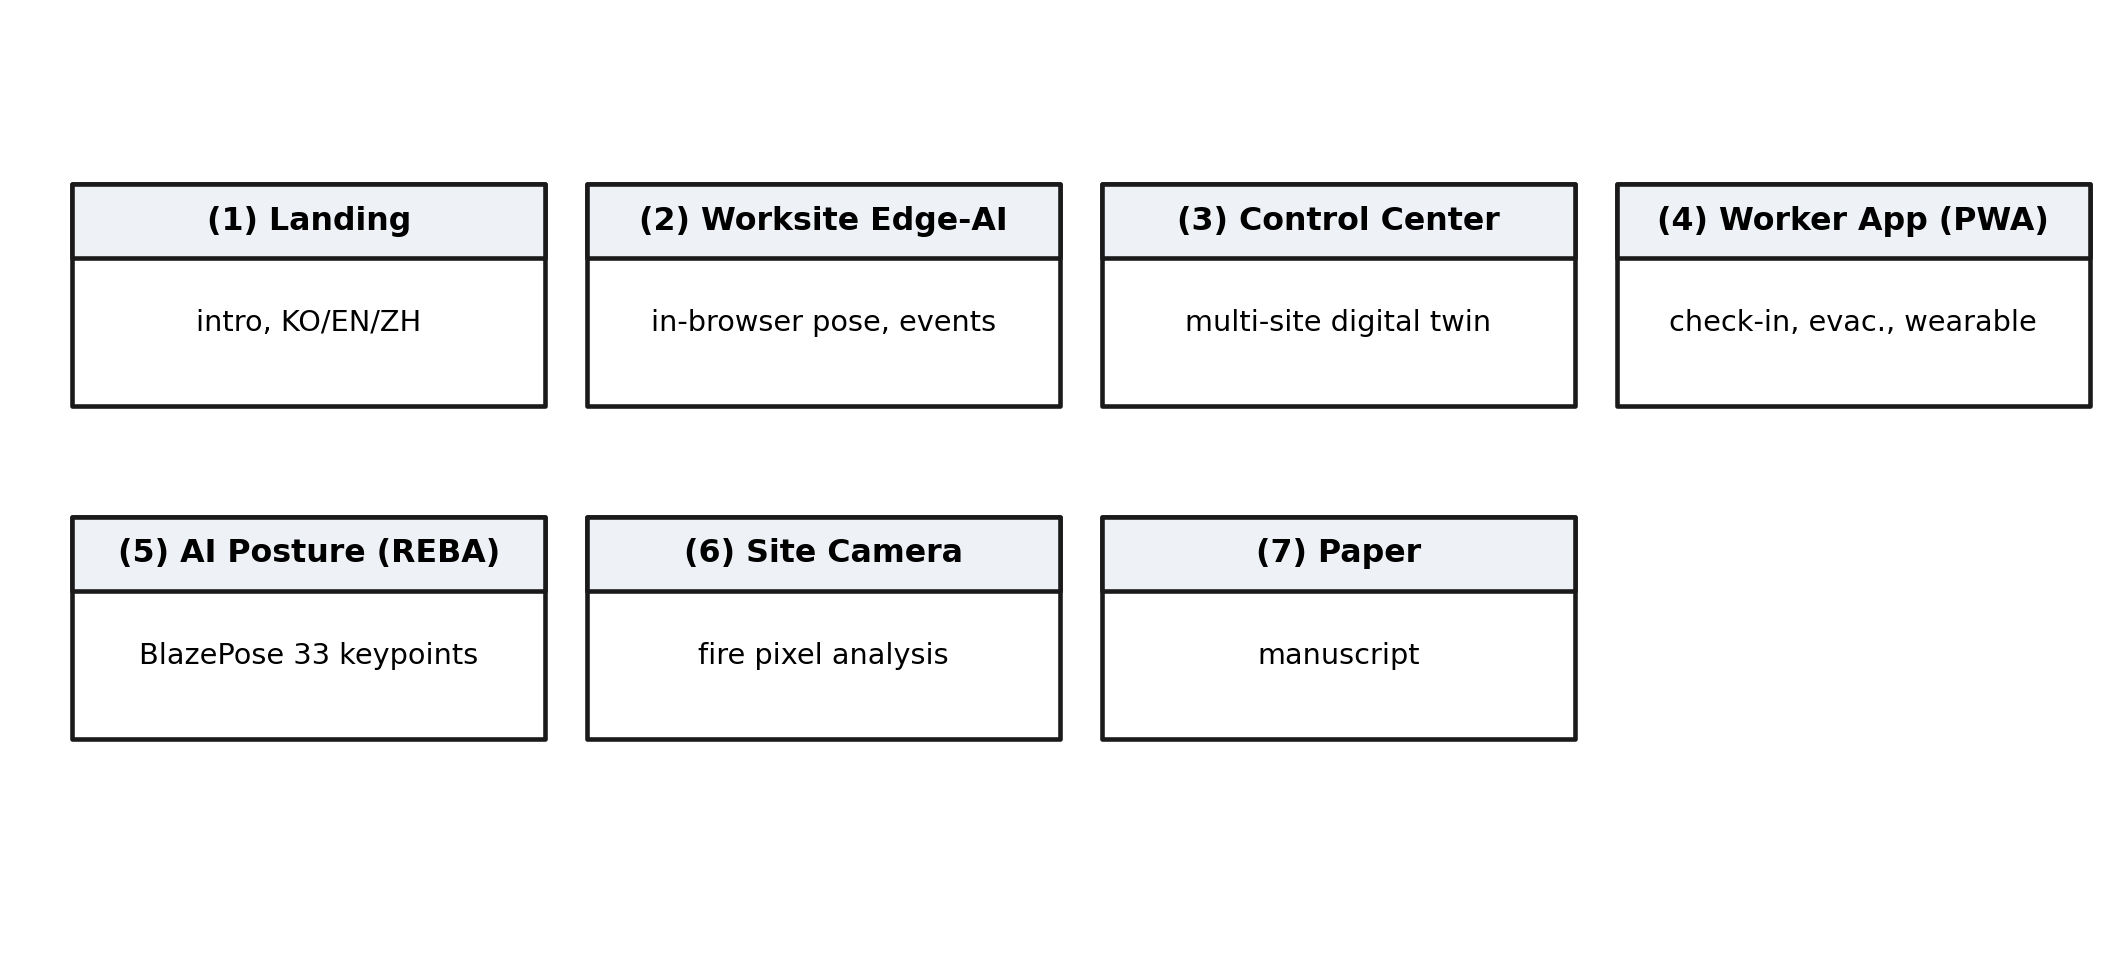

fig3_dataflow


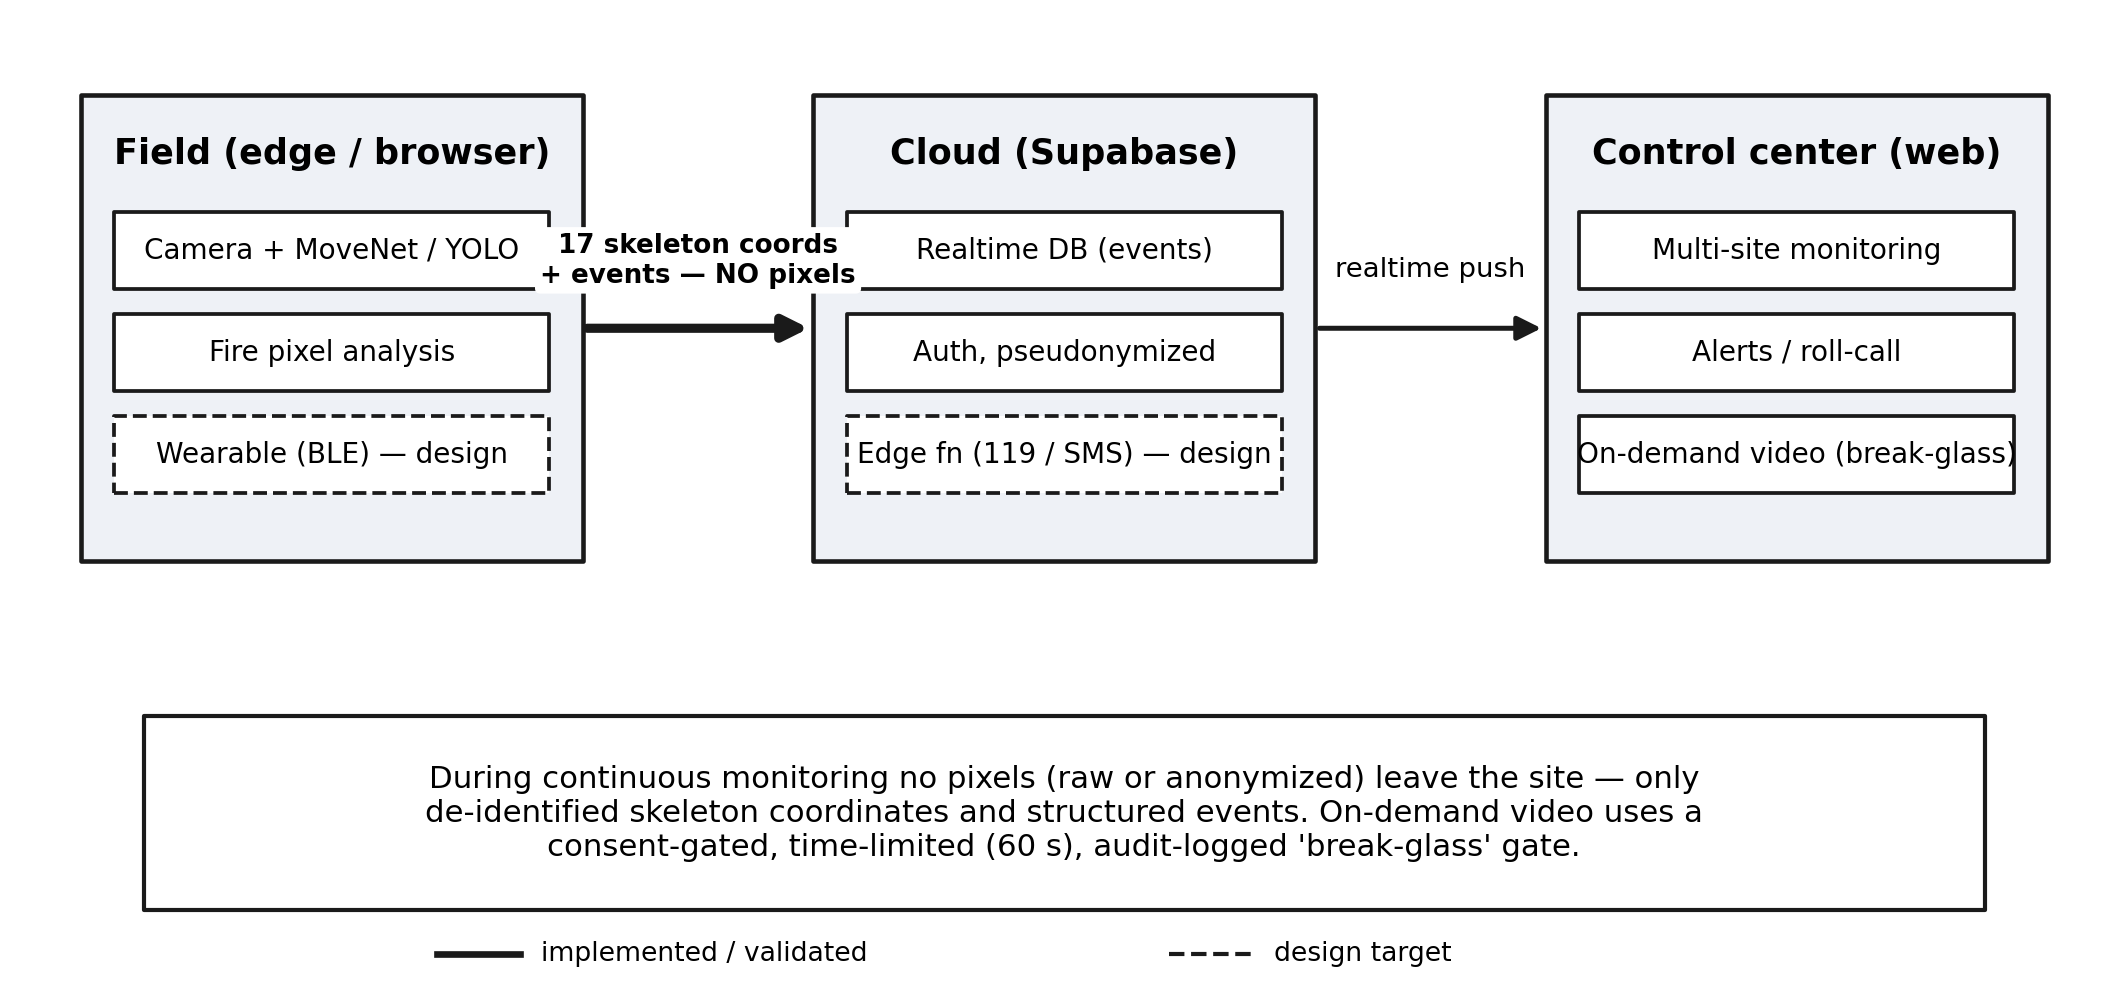

fig4_workflow


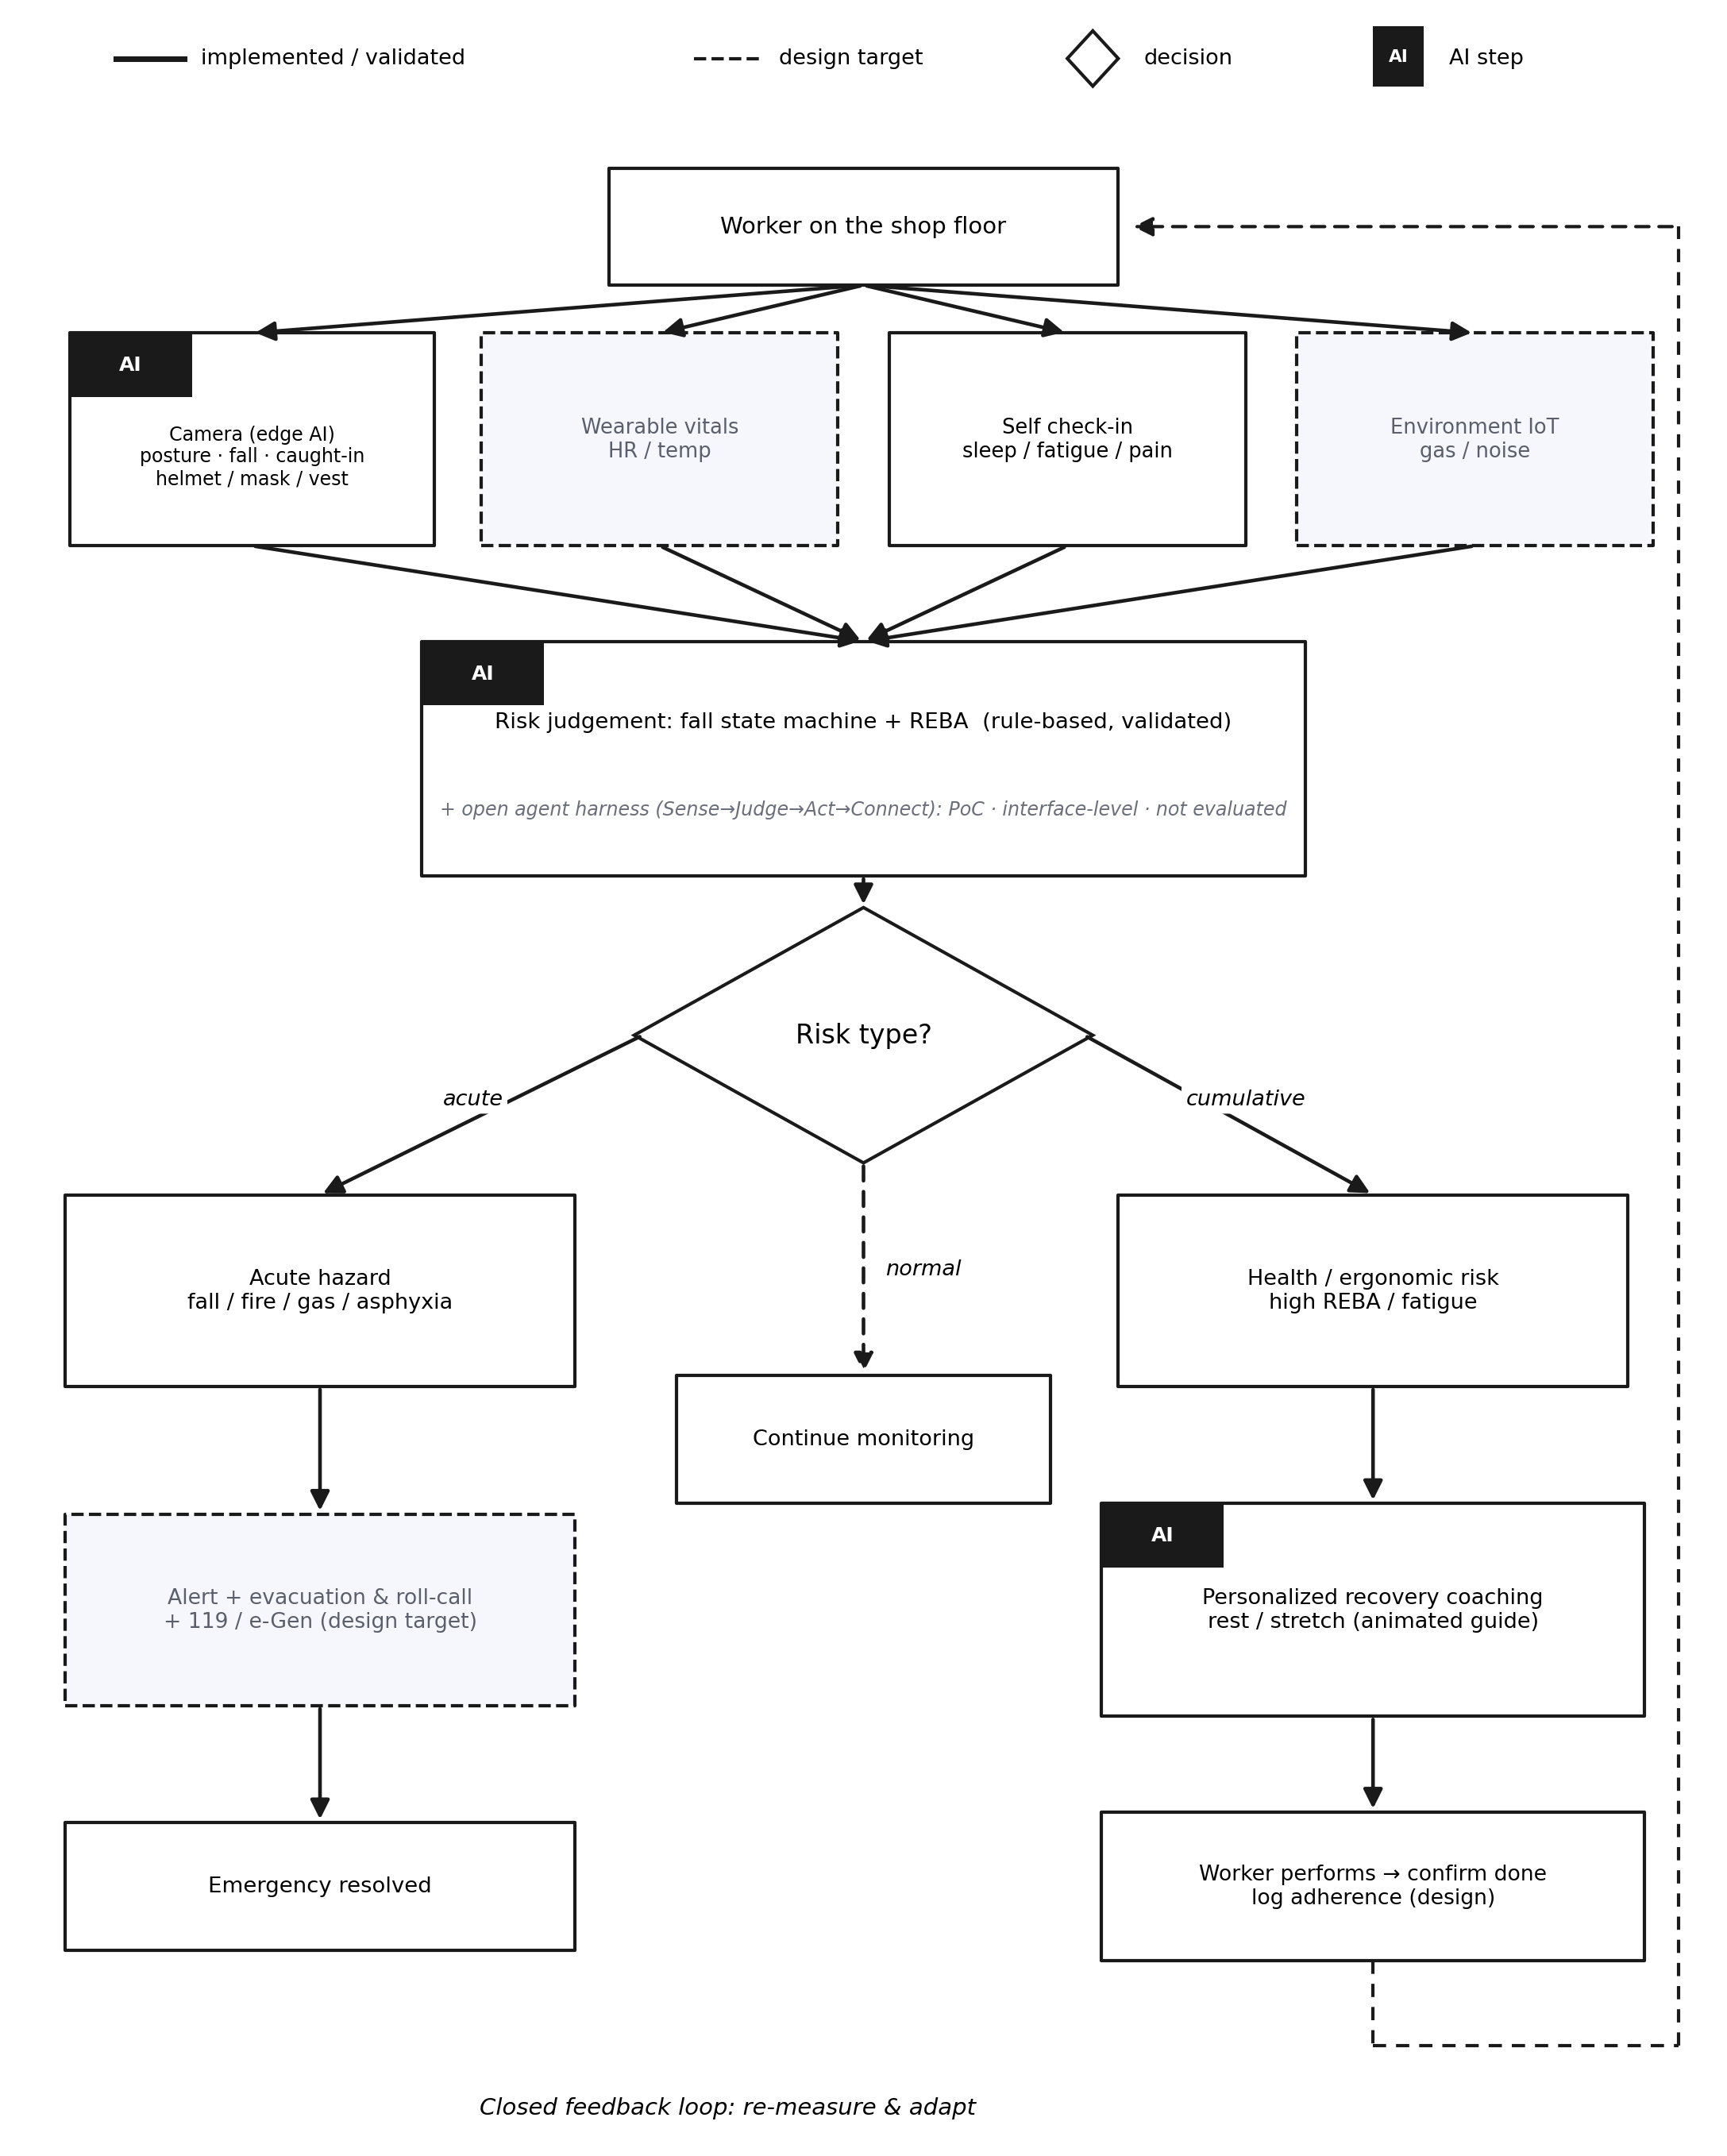

In [4]:
from IPython.display import Image, display
for f in ['fig1_architecture','fig2_system_overview','fig3_dataflow','fig4_workflow']:
    print(f); display(Image(filename=f'{__import__("os").environ.get("OUT_FIG","figures")}/{f}.png'))


## 2. Recovery-exercise animation guides (GIF)
Simple stick-figure loops used in the worker app. Saved to `figures/recovery/*.gif`.


In [5]:
# -*- coding: utf-8 -*-
"""회복 운동 가이드 GIF (스틱맨, 오프라인 생성)."""
import os, math
from PIL import Image, ImageDraw
import os
OUT=os.environ.get("OUT_REC","./figures/recovery"); os.makedirs(OUT, exist_ok=True)
W,H=260,200; CX=W//2; BLUE=(37,99,235); INK=(20,30,55); GRID=(230,238,250)

def base(d):
    d.rectangle([0,0,W,H],fill=(247,250,255))
    for x in range(0,W,20): d.line([(x,0),(x,H)],fill=GRID)
    for y in range(0,H,20): d.line([(0,y),(W,y)],fill=GRID)

def figure(d,hip_y=150,head_dx=0,arm="down",lean=0,col=INK):
    cx=CX+lean
    head=(cx+head_dx,hip_y-78)
    d.ellipse([head[0]-13,head[1]-13,head[0]+13,head[1]+13],outline=col,width=5)
    neck=(cx,hip_y-62); d.line([(head[0],head[1]+13),neck],fill=col,width=5)
    d.line([neck,(cx,hip_y)],fill=col,width=6)              # spine
    # legs
    d.line([(cx,hip_y),(cx-20,hip_y+45)],fill=col,width=6)
    d.line([(cx,hip_y),(cx+20,hip_y+45)],fill=col,width=6)
    sh=(cx,hip_y-50)
    if arm=="up":
        d.line([sh,(cx-30,hip_y-92)],fill=BLUE,width=6); d.line([sh,(cx+30,hip_y-92)],fill=BLUE,width=6)
    elif arm=="side":
        d.line([sh,(cx-42,hip_y-50)],fill=BLUE,width=6); d.line([sh,(cx+42,hip_y-50)],fill=BLUE,width=6)
    else:
        d.line([sh,(cx-20,hip_y-18)],fill=BLUE,width=6); d.line([sh,(cx+20,hip_y-18)],fill=BLUE,width=6)

def save(frames,name,dur=140):
    frames[0].save(f"{OUT}/{name}",save_all=True,append_images=frames[1:],duration=dur,loop=0,disposal=2)
    print(name, os.path.getsize(f"{OUT}/{name}")//1024,"KB")

# 1) 스트레칭 (팔 위로 + 좌우 측면 신전)
def stretch():
    fr=[]
    seq=[("down",0),("side",0),("up",0),("up",-10),("up",0),("up",10),("up",0),("side",0)]
    for arm,lean in seq:
        im=Image.new("RGB",(W,H)); d=ImageDraw.Draw(im); base(d); figure(d,arm=arm,lean=lean)
        d.text((10,8),"Stretch",fill=BLUE); fr.append(im)
    save(fr,"stretch.gif")

# 2) 목 풀기 (머리 좌우)
def neck():
    fr=[]
    for k in [0,-10,-16,-10,0,10,16,10]:
        im=Image.new("RGB",(W,H)); d=ImageDraw.Draw(im); base(d); figure(d,head_dx=k,arm="down")
        d.text((10,8),"Neck loosen",fill=BLUE); fr.append(im)
    save(fr,"neck.gif")

# 3) 휴식/호흡 (어깨 상하 + Zzz)
def rest():
    fr=[]
    for i in range(8):
        off=int(4*math.sin(i/8*2*math.pi))
        im=Image.new("RGB",(W,H)); d=ImageDraw.Draw(im); base(d); figure(d,hip_y=150+off,arm="down")
        d.text((10,8),"Rest / breathe",fill=BLUE)
        if i%4<2: d.text((CX+30,60),"z z",fill=INK)
        fr.append(im)
    save(fr,"rest.gif",dur=200)

stretch(); neck(); rest()



stretch.gif 22 KB
neck.gif 23 KB
rest.gif 25 KB


stretch


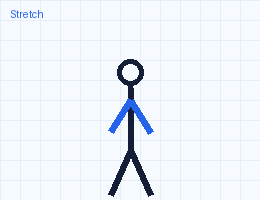

neck


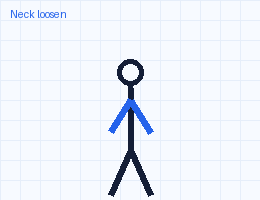

rest


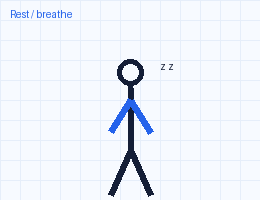

In [6]:
from IPython.display import Image, display
for g in ['stretch','neck','rest']:
    print(g); display(Image(filename=f'{__import__("os").environ.get("OUT_REC","figures/recovery")}/{g}.gif'))


## 3. Post-processing overhead (appendix, NOT a system result)
Times the two-cue posture-strain-index arithmetic and the fire pixel-scan on **synthetic inputs**, with warm-up + repeated trials (mean +/- stdev). **Neural inference is excluded** and this is **not** end-to-end FPS — label it *post-processing overhead* and keep it in an appendix. Saved to `logs/bench.json`.

In [7]:
%%writefile bench.js
// SHine-K post-processing micro-benchmark — warm-up + repeated trials + variance.
// SCOPE: post-processing CPU cost on SYNTHETIC inputs ONLY. Neural inference (MoveNet/PPE) is browser-side and EXCLUDED.
// This is NOT end-to-end FPS. Report as appendix-grade overhead, never as system performance.
function lcg(seed){let s=seed>>>0;return function(){s=(1664525*s+1013904223)>>>0;return s/4294967296;};}
var SEED=12345; var rnd=lcg(SEED);
function angle(a,b,c){const ab={x:a.x-b.x,y:a.y-b.y},cb={x:c.x-b.x,y:c.y-b.y};
  const dot=ab.x*cb.x+ab.y*cb.y;const m=Math.hypot(ab.x,ab.y)*Math.hypot(cb.x,cb.y)||1e-6;
  return Math.acos(Math.max(-1,Math.min(1,dot/m)))*180/Math.PI;}
function vTrunk(sh,hip){const dx=sh.x-hip.x,dy=sh.y-hip.y;return Math.abs(Math.atan2(dx,-dy)*180/Math.PI);}
function reba(lm){const shM={x:(lm[11].x+lm[12].x)/2,y:(lm[11].y+lm[12].y)/2};
  const hipM={x:(lm[23].x+lm[24].x)/2,y:(lm[23].y+lm[24].y)/2};
  const trunk=vTrunk(shM,hipM);const arm=180-angle(lm[23],lm[11],lm[13]);
  let r=1;if(trunk>20||arm>45)r=2;if(trunk>45||arm>90)r=3;if(trunk>60||arm>120)r=4;return [r];}
function fire(d,w,h){let flame=0,grayLow=0;const n=w*h;
  for(let i=0,p=0;i<d.length;i+=4,p++){const r=d[i],g=d[i+1],b=d[i+2];
    const mx=Math.max(r,g,b),mn=Math.min(r,g,b);
    if(r>180&&g>80&&g<200&&b<110&&r>=g&&g>=b&&(mx-mn)>40)flame++;
    const sat=mx===0?0:(mx-mn)/mx;if(sat<0.18&&((r+g+b)/3)>90&&((r+g+b)/3)<210)grayLow++;}
  return [flame/n*100];}
const lm=Array.from({length:33},()=>({x:rnd(),y:rnd()}));
const W=80,H=60;const img=new Uint8ClampedArray(W*H*4);
for(let i=0;i<img.length;i++)img[i]=Math.floor(rnd()*256);
function trialMs(fn,iters){const t0=process.hrtime.bigint();let s=0;for(let i=0;i<iters;i++){const r=fn();s+=(r&&r[0])||0;}return Number(process.hrtime.bigint()-t0)/1e6/iters;}
function stats(a){a=a.slice().sort((x,y)=>x-y);const n=a.length;const mean=a.reduce((p,c)=>p+c,0)/n;
  const sd=Math.sqrt(a.reduce((p,c)=>p+(c-mean)*(c-mean),0)/n);const med=n%2?a[(n-1)/2]:(a[n/2-1]+a[n/2])/2;
  return {mean:mean,stdev:sd,median:med,min:a[0],max:a[n-1],n:n};}
const WARMUP=3, TRIALS=15, RI=50000, FI=20000;
for(let w=0;w<WARMUP;w++){trialMs(()=>reba(lm),RI);trialMs(()=>fire(img,W,H),FI);}
const rebaT=[],fireT=[];
for(let t=0;t<TRIALS;t++){rebaT.push(trialMs(()=>reba(lm),RI));fireT.push(trialMs(()=>fire(img,W,H),FI));}
const R=stats(rebaT), F=stats(fireT);
function f4(x){return x.toFixed(4);}
console.log("SHine-K post-processing micro-benchmark (synthetic inputs; neural inference EXCLUDED; Node "+process.version+")");
console.log("Posture : "+f4(R.mean)+" +/- "+f4(R.stdev)+" ms/frame (median "+f4(R.median)+", min "+f4(R.min)+", n="+R.n+")");
console.log("Fire    : "+f4(F.mean)+" +/- "+f4(F.stdev)+" ms/frame (80x60; median "+f4(F.median)+")");
console.log("Total   : "+f4(R.mean+F.mean)+" ms/frame (mean)");
const out={tool:"shinek-postproc-microbench",
  scope:"post-processing CPU only; synthetic inputs; neural inference excluded; Node runtime (not browser)",
  seed:SEED, warmup:WARMUP, trials:TRIALS, reba_iters:RI, fire_iters:FI, node:process.version,
  reba_ms:R, fire_ms:F, total_ms_mean:R.mean+F.mean, units:"ms/frame",
  input:"33 LCG-seeded random landmarks; 80x60 LCG-seeded random RGBA"};
console.log("__JSON__"+JSON.stringify(out));


Writing bench.js


In [8]:
# Run bench, capture stdout to the run folder, and extract machine-readable JSON for the manifest.
import subprocess, json
proc = subprocess.run(["node", "bench.js"], capture_output=True, text=True)
print(proc.stdout)
if proc.stderr.strip():
    print("[stderr]", proc.stderr[:500])
(LOG_DIR / "bench_stdout.txt").write_text(proc.stdout)
BENCH = None
for line in proc.stdout.splitlines():
    if line.startswith("__JSON__"):
        BENCH = json.loads(line[len("__JSON__"):])
        (LOG_DIR / "bench.json").write_text(json.dumps(BENCH, indent=2))
        break
print("saved logs/bench.json:", BENCH is not None)


SHine-K post-processing micro-benchmark (synthetic inputs; neural inference EXCLUDED; Node v20.19.0)
Posture : 0.0003 +/- 0.0000 ms/frame (median 0.0003, min 0.0003, n=15)
Fire    : 0.1085 +/- 0.0039 ms/frame (80x60; median 0.1091)
Total   : 0.1088 ms/frame (mean)
__JSON__{"tool":"shinek-postproc-microbench","scope":"post-processing CPU only; synthetic inputs; neural inference excluded; Node runtime (not browser)","seed":12345,"warmup":3,"trials":15,"reba_iters":50000,"fire_iters":20000,"node":"v20.19.0","reba_ms":{"mean":0.00027860616,"stdev":0.000004871073536235447,"median":0.00027639218,"min":0.00027470888,"max":0.00029121075999999997,"n":15},"fire_ms":{"mean":0.10848976610333333,"stdev":0.003921699435348374,"median":0.10905187755,"min":0.0945767899,"max":0.11407169225,"n":15},"total_ms_mean":0.10876837226333333,"units":"ms/frame","input":"33 LCG-seeded random landmarks; 80x60 LCG-seeded random RGBA"}

saved logs/bench.json: True


## 5. REAL EVALUATION — fall detection on UR Fall Detection Dataset (URFD)
This is the one **measured result** for the paper: the *same* skeleton fall state machine used in the SHine-K worksite app, evaluated on a **public dataset** with MoveNet — reporting precision / recall / F1, a confusion matrix, and detection latency. Saved to the run folder (`eval_metrics.json`, `eval_per_sequence.csv`, `eval_confusion_matrix.png`).

> Honesty: URFD is clean single-subject lab footage with a fixed camera — it bounds generalization and is **not** SME shop-floor performance. It validates the pose->state-machine logic, not multi-person association. Set `URFD_N_FALL`/`URFD_N_ADL` env vars to use the full 30/40 sequences; defaults use a subset for the free tier.

In [9]:
# Eval-only deps (kept out of the top install so figures/bench stay light). First Colab run: ~1-2 min.
!pip -q install tensorflow tensorflow-hub opencv-python-headless numpy matplotlib 2>/dev/null
print("eval deps ready")


eval deps ready


In [10]:
# === URFD fall-detection evaluation (guarded: skips gracefully if TF / network / data unavailable) ===
EVAL = None
try:
    import io, csv, json, math, zipfile, urllib.request
    import numpy as np
    import tensorflow as tf, tensorflow_hub as hub
    import cv2

    N_FALL = int(os.environ.get("URFD_N_FALL", "8"))   # full dataset = 30
    N_ADL  = int(os.environ.get("URFD_N_ADL",  "8"))   # full dataset = 40
    FRAME_STRIDE = int(os.environ.get("URFD_STRIDE", "1"))
    BASE_URL = "http://fenix.ur.edu.pl/~mkepski/ds/data"
    CACHE = BASE_OUTPUT / "_urfd_cache"; CACHE.mkdir(parents=True, exist_ok=True)

    print("Loading MoveNet MultiPose Lightning (matches the deployed model) ...")
    _net = hub.load("https://tfhub.dev/google/movenet/multipose/lightning/1")
    _infer = _net.signatures["serving_default"]

    def movenet_kps(frame_rgb):
        # -> (kps[17x(x_px,y_px,score)], W, H) for the top-scoring person, or None
        H, W = frame_rgb.shape[:2]
        img = tf.image.resize_with_pad(tf.expand_dims(frame_rgb, 0), 256, 256)
        img = tf.cast(img, dtype=tf.int32)
        res = _infer(tf.constant(img))["output_0"].numpy()[0]   # (6,56)
        best, bs = None, -1.0
        for person in res:
            kp = person[:51].reshape(17, 3)                      # [y,x,score] in padded 256 space
            sc = float(kp[:, 2].mean())
            if sc > bs: bs, best = sc, kp
        if best is None: return None
        scale = 256.0 / max(H, W); padx = (256 - W*scale)/2; pady = (256 - H*scale)/2
        out = np.zeros((17, 3))
        for i in range(17):
            yn, xn, s = best[i]
            out[i] = [(xn*256 - padx)/scale, (yn*256 - pady)/scale, s]
        return out, W, H

    # ---- faithful port of analyzePerson() from worksite_multi.html (deployed defaults, sens=1.0) ----
    ACT_IDX = [0, 5, 6, 9, 10, 11, 12, 15, 16]
    class FallSM:
        def __init__(self, fps=30.0, sens=1.0):
            self.fps=float(fps); self.sens=float(sens); self.reset()
        def reset(self):
            self.t=0.0; self.frame=-1; self.downSince=None; self.staticSince=None
            self.hipHist=[]; self.lastKp=None; self.state="normal"
            self.triggered=False; self.trigger_frame=None
        def _v(self, kps, i):
            x,y,s = kps[i]; return (x,y) if s>0.3 else None
        def step(self, kps, W, H):
            self.frame += 1; self.t += 1.0/self.fps; now = self.t*1000.0
            shL=self._v(kps,5); shR=self._v(kps,6); hipL=self._v(kps,11); hipR=self._v(kps,12)
            if shL is None or shR is None:
                self.state="normal"; self.lastKp=kps; return self.state
            shX=(shL[0]+shR[0])/2; shY=(shL[1]+shR[1])/2
            if hipL and hipR: hpX=(hipL[0]+hipR[0])/2; hpY=(hipL[1]+hipR[1])/2
            else:
                sw=math.hypot(shR[0]-shL[0], shR[1]-shL[1]); hpX=shX; hpY=shY+sw*1.4
            dx=shX-hpX; dy=shY-hpY
            tilt=math.degrees(math.atan2(abs(dx), abs(dy)))
            xs=[]; ys=[]
            for j in range(17):
                if kps[j][2]>0.3: xs.append(kps[j][0]); ys.append(kps[j][1])
            aspect=((max(xs)-min(xs))/max(1.0,(max(ys)-min(ys)))) if len(xs)>=2 else 0.0
            self.hipHist.append((hpY/H, self.t))
            if len(self.hipHist)>8: self.hipHist.pop(0)
            vel=0.0
            if len(self.hipHist)>=2:
                a=self.hipHist[0]; z=self.hipHist[-1]; vel=(z[0]-a[0])/max(0.001,(z[1]-a[1]))
            mv=0.0
            if self.lastKp is not None:
                sm=0.0; nm=0
                for i in ACT_IDX:
                    c=kps[i]; l=self.lastKp[i]
                    if c[2]>0.3 and l[2]>0.3:
                        sm+=math.hypot((c[0]-l[0])/W, (c[1]-l[1])/H); nm+=1
                mv=(sm/nm) if nm else 0.0
            self.lastKp=kps
            TILT_DOWN=52*self.sens; ASP_DOWN=1.0*self.sens; VEL_DROP=0.9/self.sens
            isDown=(tilt>TILT_DOWN) or (aspect>ASP_DOWN); rapid=vel>VEL_DROP
            if isDown:
                if not self.downSince: self.downSince=now
                self.state="fall" if (now-self.downSince>700) else "warn"
            elif rapid:
                self.state="warn"; self.downSince=None
            else:
                self.state="normal"; self.downSince=None
            if self.state=="normal":
                if mv<0.0045:
                    if not self.staticSince: self.staticSince=now
                    ss=(now-self.staticSince)/1000.0
                    if mv<0.0016 and ss>12: self.state="inactive"
                    elif ss>25: self.state="sedentary"
                else: self.staticSince=None
            else: self.staticSince=None
            if self.state in ("fall","inactive") and not self.triggered:
                self.triggered=True; self.trigger_frame=self.frame
            return self.state

    def load_frames(name):
        url=f"{BASE_URL}/{name}-cam0-rgb.zip"; zp=CACHE/f"{name}.zip"
        if not zp.exists(): urllib.request.urlretrieve(url, zp)
        frames=[]
        with zipfile.ZipFile(zp) as z:
            ns=sorted(n for n in z.namelist() if n.lower().endswith((".png",".jpg",".jpeg")))
            for k,n in enumerate(ns):
                if k % FRAME_STRIDE: continue
                arr=cv2.imdecode(np.frombuffer(z.read(n), np.uint8), cv2.IMREAD_COLOR)
                if arr is not None: frames.append(cv2.cvtColor(arr, cv2.COLOR_BGR2RGB))
        return frames

    seqs=[(f"fall-{i:02d}",1) for i in range(1,N_FALL+1)] + [(f"adl-{i:02d}",0) for i in range(1,N_ADL+1)]
    rows=[]; TP=FP=FN=TN=0; lat=[]
    for name,gt in seqs:
        try:
            frames=load_frames(name)
        except Exception as e:
            print("  skip", name, "-", e); continue
        if not frames: print("  no frames", name); continue
        sm=FallSM(fps=30.0/FRAME_STRIDE)
        for f in frames:
            r=movenet_kps(f)
            if r is None: sm.step([(0,0,0.0)]*17, f.shape[1], f.shape[0])
            else: sm.step(r[0], r[1], r[2])
        pred=1 if sm.triggered else 0
        rows.append({"seq":name,"gt":gt,"pred":pred,"trigger_frame":sm.trigger_frame,"frames":len(frames)})
        if   gt==1 and pred==1: TP+=1; lat.append(sm.trigger_frame if sm.trigger_frame is not None else len(frames))
        elif gt==0 and pred==1: FP+=1
        elif gt==1 and pred==0: FN+=1
        else: TN+=1
        print(f"  {name}: gt={gt} pred={pred} trig={sm.trigger_frame}")

    prec=TP/(TP+FP) if (TP+FP) else 0.0
    rec =TP/(TP+FN) if (TP+FN) else 0.0
    f1  =2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    acc =(TP+TN)/max(1,(TP+FP+FN+TN))
    EVAL={"dataset":"UR Fall Detection (URFD), cam0 RGB",
          "model":"MoveNet MultiPose Lightning (TF-Hub)",
          "state_machine":"faithful port of worksite_multi.html analyzePerson(), deployed defaults (sens=1.0)",
          "n_fall":N_FALL,"n_adl":N_ADL,"frame_stride":FRAME_STRIDE,
          "counts":{"TP":TP,"FP":FP,"FN":FN,"TN":TN},
          "precision":round(prec,4),"recall":round(rec,4),"f1":round(f1,4),"accuracy":round(acc,4),
          "detection_latency_frames":{"mean":(float(np.mean(lat)) if lat else None),
                                       "median":(float(np.median(lat)) if lat else None)},
          "caveat":"URFD = clean single-subject lab footage, fixed camera. Bounds generalization; != SME shop-floor. Evaluates pose->state-machine logic, not multi-person association. Thresholds unchanged from deployment."}
    (RUN_DIR/"eval_metrics.json").write_text(json.dumps(EVAL, indent=2, ensure_ascii=False))
    with open(RUN_DIR/"eval_per_sequence.csv","w",newline="") as fh:
        w=csv.DictWriter(fh, fieldnames=["seq","gt","pred","trigger_frame","frames"]); w.writeheader(); w.writerows(rows)
    import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    cm=np.array([[TN,FP],[FN,TP]]); mx=max(1,cm.max())
    fig,ax=plt.subplots(figsize=(3.5,3.3))  # publication B/W style (matches paper Fig.)
    for (r_,c_),v in np.ndenumerate(cm):
        sh=0.93-0.30*(v/mx)
        ax.add_patch(Rectangle((c_,1-r_),1,1,fc=(sh,sh,sh),ec="#1a1a1a",lw=1.2))
        ax.text(c_+0.5,1-r_+0.5,int(v),ha="center",va="center",fontsize=16,fontweight="bold",color="#000")
    ax.set_xlim(0,2); ax.set_ylim(0,2); ax.set_aspect("equal")
    ax.set_xticks([0.5,1.5]); ax.set_xticklabels(["pred ADL","pred Fall"],fontsize=9)
    ax.set_yticks([1.5,0.5]); ax.set_yticklabels(["true ADL","true Fall"],fontsize=9)
    ax.tick_params(length=0)
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_title("URFD fall detection (%d fall + %d ADL)\nPrecision %.2f  Recall %.2f  F1 %.2f"%(N_FALL,N_ADL,prec,rec,f1),fontsize=9.5,pad=8)
    fig.savefig(RUN_DIR/"eval_confusion_matrix.png", dpi=300, bbox_inches="tight", pad_inches=0.08); plt.close(fig)
    print("\nEVAL:", json.dumps(EVAL, ensure_ascii=False, indent=2))
except Exception as e:
    import traceback; traceback.print_exc()
    print("\n[eval skipped]", repr(e))
    print("-> Harness/manifest still proceed. Re-run in Colab with TF + internet to produce the real fall-detection result.")
    EVAL = None


Loading MoveNet MultiPose Lightning (matches the deployed model) ...
  fall-01: gt=1 pred=1 trig=150
  fall-02: gt=1 pred=1 trig=81
  fall-03: gt=1 pred=1 trig=202
  fall-04: gt=1 pred=1 trig=41
  fall-05: gt=1 pred=1 trig=118
  fall-06: gt=1 pred=1 trig=57
  fall-07: gt=1 pred=1 trig=122
  fall-08: gt=1 pred=1 trig=51
  adl-01: gt=0 pred=0 trig=None
  adl-02: gt=0 pred=0 trig=None
  adl-03: gt=0 pred=0 trig=None
  adl-04: gt=0 pred=1 trig=95
  adl-05: gt=0 pred=1 trig=124
  adl-06: gt=0 pred=1 trig=193
  adl-07: gt=0 pred=0 trig=None
  adl-08: gt=0 pred=0 trig=None

EVAL: {
  "dataset": "UR Fall Detection (URFD), cam0 RGB",
  "model": "MoveNet MultiPose Lightning (TF-Hub)",
  "state_machine": "faithful port of worksite_multi.html analyzePerson(), deployed defaults (sens=1.0)",
  "n_fall": 8,
  "n_adl": 8,
  "frame_stride": 1,
  "counts": {
    "TP": 8,
    "FP": 3,
    "FN": 0,
    "TN": 5
  },
  "precision": 0.7273,
  "recall": 1.0,
  "f1": 0.8421,
  "accuracy": 0.8125,
  "detection_

In [11]:
# === run_manifest.json — provenance for this run (env, versions, measured numbers, content hashes) ===
import importlib
def _ver(mod):
    try: return importlib.import_module(mod).__version__
    except Exception: return None
def _node_ver():
    try: return subprocess.run(["node","--version"],capture_output=True,text=True).stdout.strip()
    except Exception: return None
def _git():
    try:
        base = DRIVE_REPO or (REPO_LOCAL if REPO_LOCAL.exists() else None)
        if not base: return None
        return subprocess.run(["git","-C",str(base),"rev-parse","--short","HEAD"],capture_output=True,text=True).stdout.strip() or None
    except Exception: return None
def _sha256(p):
    h=hashlib.sha256()
    with open(p,"rb") as f:
        for ch in iter(lambda: f.read(65536), b""): h.update(ch)
    return h.hexdigest()

contents=[]
for root,_,files in os.walk(RUN_DIR):
    for fn in files:
        fp=Path(root)/fn
        contents.append({"path":str(fp.relative_to(RUN_DIR)),"bytes":fp.stat().st_size,"sha256":_sha256(fp)})

MEASUREMENT_SCOPE = ("Post-processing CPU cost only, on randomly-generated inputs (33 random landmarks; 80x60 random RGBA). "
  "Model inference is browser-side and EXCLUDED. Not end-to-end FPS. DESIGN-TARGET metrics "
  "(e.g., 97.8% accuracy, 340% ROI, 65% injury reduction, 10-second 119 dispatch) are NOT measured here. "
  "The URFD fall-detection block (eval_metrics.json), when present, is the one measured accuracy result.")

manifest={
  "run_id": RUN_ID,
  "timestamp": RUN_TIMES,
  "seed": SEED,
  "environment": {
    "in_colab": IN_COLAB,
    "python": sys.version.split()[0],
    "node": _node_ver(),
    "platform": platform.platform(),
    "machine": platform.machine(),
    "processor": platform.processor(),
    "cpu_count": os.cpu_count(),
    "packages": {m:_ver(m) for m in ["numpy","matplotlib","PIL","tensorflow","tensorflow_hub","cv2"]},
  },
  "git_commit": _git(),
  "measurement_scope": MEASUREMENT_SCOPE,
  "latency_benchmark": (BENCH if "BENCH" in globals() else None),
  "fall_detection_eval": (EVAL if "EVAL" in globals() else None),
  "contents": sorted(contents, key=lambda x: x["path"]),
}
(RUN_DIR/"run_manifest.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print("wrote", RUN_DIR/"run_manifest.json", "(%d files)" % len(contents))
print(json.dumps({k:manifest[k] for k in ("run_id","timestamp","git_commit")}, indent=2, ensure_ascii=False))


wrote /content/output/run_20260627_231823/run_manifest.json (12 files)
{
  "run_id": "run_20260627_231823",
  "timestamp": {
    "utc_iso": "2026-06-27T14:18:23.548949+00:00",
    "kst_iso": "2026-06-27T23:18:23.548949+09:00",
    "tz_offset": "+09:00",
    "epoch": 1782569903.548949
  },
  "git_commit": null
}


In [12]:
# === Mirror to Drive (if mounted), zip the run, and download (Colab) — triple-copy insurance ===
if DRIVE_REPO:
    try:
        dst = DRIVE_REPO / "output" / RUN_ID
        shutil.copytree(RUN_DIR, dst, dirs_exist_ok=True)
        print("mirrored to Drive:", dst)
    except Exception as e:
        print("Drive mirror skipped:", e)

zip_base = str(BASE_OUTPUT / RUN_ID)
zip_path = shutil.make_archive(zip_base, "zip", root_dir=str(RUN_DIR))
print("zipped:", zip_path)

if IN_COLAB:
    try:
        from google.colab import files
        files.download(zip_path)
    except Exception as e:
        print("download skipped:", e)
print("DONE — results for this run are in:", RUN_DIR)


mirrored to Drive: /content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문3/코드/output/run_20260627_231823
zipped: /content/output/run_20260627_231823.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DONE — results for this run are in: /content/output/run_20260627_231823


## 6. Revision & paper notes
- Every run -> `output/run_<KST timestamp>/` with `run_manifest.json` (env, versions, hashes, measured numbers). Cite results by run id for provenance.
- **Paper Table 3**: report the URFD fall-detection metrics (precision/recall/F1) as the measured result; move the post-processing micro-bench to an appendix labelled *overhead, synthetic inputs, inference excluded*.
- Figures: edit any `figN()` and re-run; copy from the run's `figures/` into `이미지/` and rebuild the .docx via `gen_paper_en_docx_v2.py`. Keep them in *Design*, not *Results*.
- In-browser FPS is device-dependent; measure with the in-app benchmark on `pose.html` (separate from Colab FPS).